# Fine-Tuning a Pretrained Language Model

In this notebook, we'll take a pretrained language model — **DistilBERT** — and fine-tune it for **sentiment classification**: given a sentence, predict whether it's positive or negative.

**What you'll do:**
1. Understand why we fine-tune pretrained models instead of building from scratch
2. Download DistilBERT from Hugging Face
3. See that the model's predictions start out **random**
4. Fine-tune it on the SST-2 sentiment dataset
5. Watch accuracy jump from ~50% to ~90%+
6. Try your own sentences

This is the **modern AI workflow** — almost every production NLP system starts with a pretrained model and fine-tunes it for the specific task.

## 1. Background

### Why fine-tune?

Modern AI models aren't built from scratch. Training a model like BERT or GPT from zero requires billions of text tokens, weeks of compute on GPU clusters, and millions of dollars. Almost no one does this.

The standard workflow is **transfer learning**:
1. Download a **foundation model** that someone else (Google, Meta, etc.) trained on a massive amount of general text.
2. Add a small task-specific layer on top.
3. **Fine-tune** on your specific task using a much smaller dataset.

It works because the foundation model already understands language — grammar, semantics, common sense. Fine-tuning teaches it your particular task (sentiment, classification, summarization, etc.) on top of that existing knowledge.

### What is Hugging Face?

[Hugging Face](https://huggingface.co/) is the GitHub of open AI models. It hosts hundreds of thousands of pretrained models that anyone can download and use, plus Python libraries that make loading them a one-liner. The two we'll use today:
- **`transformers`** — for downloading and using pretrained models
- **`datasets`** — for loading common ML datasets without hosting your own copy

Everything is anonymous and free for public models. No API key needed.

### What is DistilBERT?

**BERT** (Google, 2018) was a seminal Transformer-based language model. **DistilBERT** is a smaller, faster version of BERT, created by Hugging Face via a technique called *knowledge distillation* (a smaller student model trained to mimic BERT's outputs).

- **40% smaller** and **60% faster** than BERT-base
- Retains ~97% of BERT's language understanding
- Same Transformer architecture as modern LLMs

It's perfect for a teaching exercise where we want training to finish in a few minutes.

## 2. Setup

We're in Colab again for the same reasons as the previous notebook — pre-installed PyTorch, free GPU access. Make sure GPU is enabled: **`Runtime → Change runtime type → T4 GPU`**.

The `transformers` and `datasets` libraries from Hugging Face are also pre-installed in Colab.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    pipeline,
    TrainingArguments,
    Trainer,

)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [2]:
!nvidia-smi

Tue Jun  2 19:42:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Load DistilBERT

We load DistilBERT with `AutoModelForSequenceClassification`. This wraps DistilBERT's pretrained Transformer body with a **fresh, randomly-initialized classification head** for binary classification (positive vs. negative).

The transformer body has been pretrained on tons of English text. The classification head has been trained on nothing — that's what fine-tuning is going to fix.

In [3]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel loaded. Total parameters: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded. Total parameters: 66,955,010


## 4. What does the base model do?

Before training, let's see what the model predicts on a few sample sentences. With a random classification head, we expect essentially random output.

We'll use Hugging Face's **`pipeline`** — a one-line wrapper that takes care of tokenization, batching, and decoding for us. Give it sentences, get back predictions.

In [4]:
classifier = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

sample_sentences = [
    "This is the best movie I have ever seen.",
    "Absolutely terrible. I want my money back.",
    "It was okay, nothing special.",
]

print("Predictions BEFORE fine-tuning:")
for sentence, result in zip(sample_sentences, classifier(sample_sentences)):
    print(f"  [{result['label']}] {sentence}")

Predictions BEFORE fine-tuning:
  [POSITIVE] This is the best movie I have ever seen.
  [POSITIVE] Absolutely terrible. I want my money back.
  [POSITIVE] It was okay, nothing special.


## 5. Load the SST-2 sentiment dataset

**SST-2** (Stanford Sentiment Treebank) is a classic benchmark dataset for sentiment classification. Each example is a single sentence labeled positive (`1`) or negative (`0`).

Loads in one line via the Hugging Face `datasets` library.

In [5]:
dataset = load_dataset("stanfordnlp/sst2")

print(dataset)
print()
print("Example training rows:")
for i in range(5):
    ex = dataset["train"][i]
    label = "POSITIVE" if ex["label"] == 1 else "NEGATIVE"
    print(f"  [{label}] {ex['sentence'].strip()}")

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Example training rows:
  [NEGATIVE] hide new secretions from the parental units
  [NEGATIVE] contains no wit , only labored gags
  [POSITIVE] that loves its characters and communicates something rather beautiful about human nature
  [NEGATIVE] remains utterly satisfied to remain the same throughout
  [NEGATIVE] on the worst revenge-of-the-nerds clichés the filmmakers could dredge up


## 6. Tokenize the text

Models read numbers, not text. The tokenizer converts each sentence into a list of integers (called *token IDs*) that the model can process.

The pipeline we used above tokenizes automatically when we call it. The Trainer (which we'll use for fine-tuning) is different — it expects the dataset to be pre-tokenized.

So we run the tokenizer over the dataset once, here, and reuse that result for both the baseline evaluation and the fine-tuning that follows.

In [6]:
def tokenize(batch):
    return tokenizer(batch["sentence"], truncation=True)

tokenized = dataset.map(tokenize, batched=True)

# A quick look at what tokenization produced
print("Original text:", dataset["train"][0]["sentence"][:60])
print("Token IDs:    ", tokenized["train"][0]["input_ids"][:15], "...")

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Original text: hide new secretions from the parental units 
Token IDs:     [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102] ...


## 7. Evaluate the base model

Let's measure how the model performs on the validation set **before any fine-tuning**. Since the classification head is random, we expect roughly chance-level accuracy (50% for binary).

In [7]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": float(accuracy)}

# A Trainer just for evaluation — no training yet
eval_args = TrainingArguments(
    output_dir="./eval_only",
    per_device_eval_batch_size=64,
    report_to="none",
)

eval_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

baseline_results = eval_trainer.evaluate()
baseline_acc = baseline_results["eval_accuracy"]
print(f"\nBaseline accuracy (no fine-tuning): {baseline_acc:.4f}")


Baseline accuracy (no fine-tuning): 0.5092


## 8. Fine-tune the model

Now we'll fine-tune for 2 epochs on the SST-2 training set. The Hugging Face `Trainer` handles the training loop, optimizer, evaluation, and progress logging for us.

Standard fine-tuning settings for BERT-family models:
- Learning rate: `2e-5`
- Batch size: 32
- Epochs: 2 (usually plenty for SST-2)
- Evaluation after each epoch

On Colab's free T4 GPU, this takes about 3–5 minutes.

In [8]:
training_args = TrainingArguments(
    output_dir="./finetuning_output",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    push_to_hub=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.169228,0.259666,0.907110
2,0.110714,0.307680,0.900229


TrainOutput(global_step=4210, training_loss=0.17075906827727294, metrics={'train_runtime': 508.1257, 'train_samples_per_second': 265.088, 'train_steps_per_second': 8.285, 'total_flos': 1401813478442976.0, 'train_loss': 0.17075906827727294, 'epoch': 2.0})

## 9. Evaluate the fine-tuned model

Same validation set, same metric — but the classification head has now been trained.

Fine-tuned accuracy: 0.9002
Baseline accuracy:   0.5092
Improvement:         39.1 percentage points


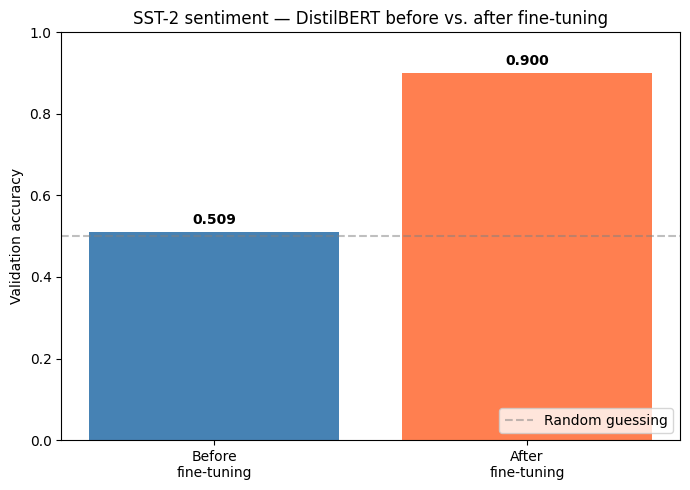

In [9]:
final_results = trainer.evaluate()
final_acc = final_results["eval_accuracy"]

print(f"Fine-tuned accuracy: {final_acc:.4f}")
print(f"Baseline accuracy:   {baseline_acc:.4f}")
print(f"Improvement:         {(final_acc - baseline_acc) * 100:.1f} percentage points")

# Visualize the before/after
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Before\nfine-tuning', 'After\nfine-tuning'],
       [baseline_acc, final_acc],
       color=['steelblue', 'coral'])
ax.set_ylim(0, 1)
ax.set_ylabel('Validation accuracy')
ax.set_title('SST-2 sentiment — DistilBERT before vs. after fine-tuning')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random guessing')
ax.legend(loc='lower right')
for i, v in enumerate([baseline_acc, final_acc]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Try your own sentences

The `classifier` pipeline we built earlier still points to the same model — which has now been fine-tuned.

Feel free to edit `custom_sentences` and re-run.

In [10]:
custom_sentences = [
    "The plot was confusing and the acting was stale.",
    "I loved every minute of it!",
    "Pretty mediocre overall.",
    "A masterpiece of cinema that will be remembered for decades.",
]

print("\nCustom sentences:")
for sentence, result in zip(custom_sentences, classifier(custom_sentences)):
    print(f"  [{result['label']}] {sentence}")


Custom sentences:
  [NEGATIVE] The plot was confusing and the acting was stale.
  [POSITIVE] I loved every minute of it!
  [NEGATIVE] Pretty mediocre overall.
  [POSITIVE] A masterpiece of cinema that will be remembered for decades.


## 11. Reflection

A few things to take away:

- **This is the modern AI workflow.** Almost every production NLP system (sentiment classifiers, support routing, content moderation, search relevance, chatbots) starts with a pretrained model and fine-tunes it. Building from scratch is rare.
- **The pretrained model did most of the work.** DistilBERT already understood English before we started — sentence structure, word meanings, common sense. Fine-tuning just taught it how to map that understanding to the specific labels we cared about (positive / negative).
- **What's next:** larger models (BERT-large, RoBERTa, Llama), longer-form tasks (summarization, Q&A), multimodal (CLIP, vision-language models). The Hugging Face workflow scales to all of them — the code looks almost identical.